In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

### LOAD DATASET





In [5]:
iris=load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [7]:
x=pd.DataFrame(iris.data,columns=iris.feature_names)

In [8]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [9]:
y=pd.Series(iris.target,name="species")

In [10]:
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int32

In [11]:
df=x.copy()
df["species"]=y


###  # EXPLORATORY DATA ANALYSIS (EDA)

In [5]:
df.shape

(150, 5)

In [6]:
df.dtypes

sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
Species               object
dtype: object

In [7]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
Species              0
dtype: int64

In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [12]:
df["species"]=df["species"].map({
    0:"setosa",
    1:"versicolor",
    2:"verginica"})


In [13]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


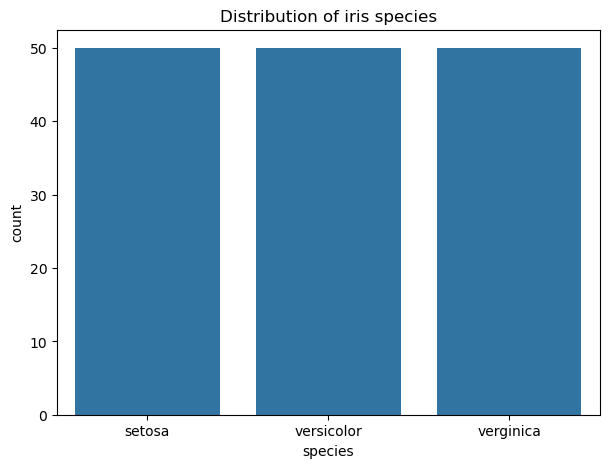

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="species")
plt.title("Distribution of iris species")
plt.xlabel("species")
plt.ylabel("count")
plt.show()

## # DATA VISUALIZATION : PAIRPLOT, BOXPLOTS, CORRELATION, HEATMAP

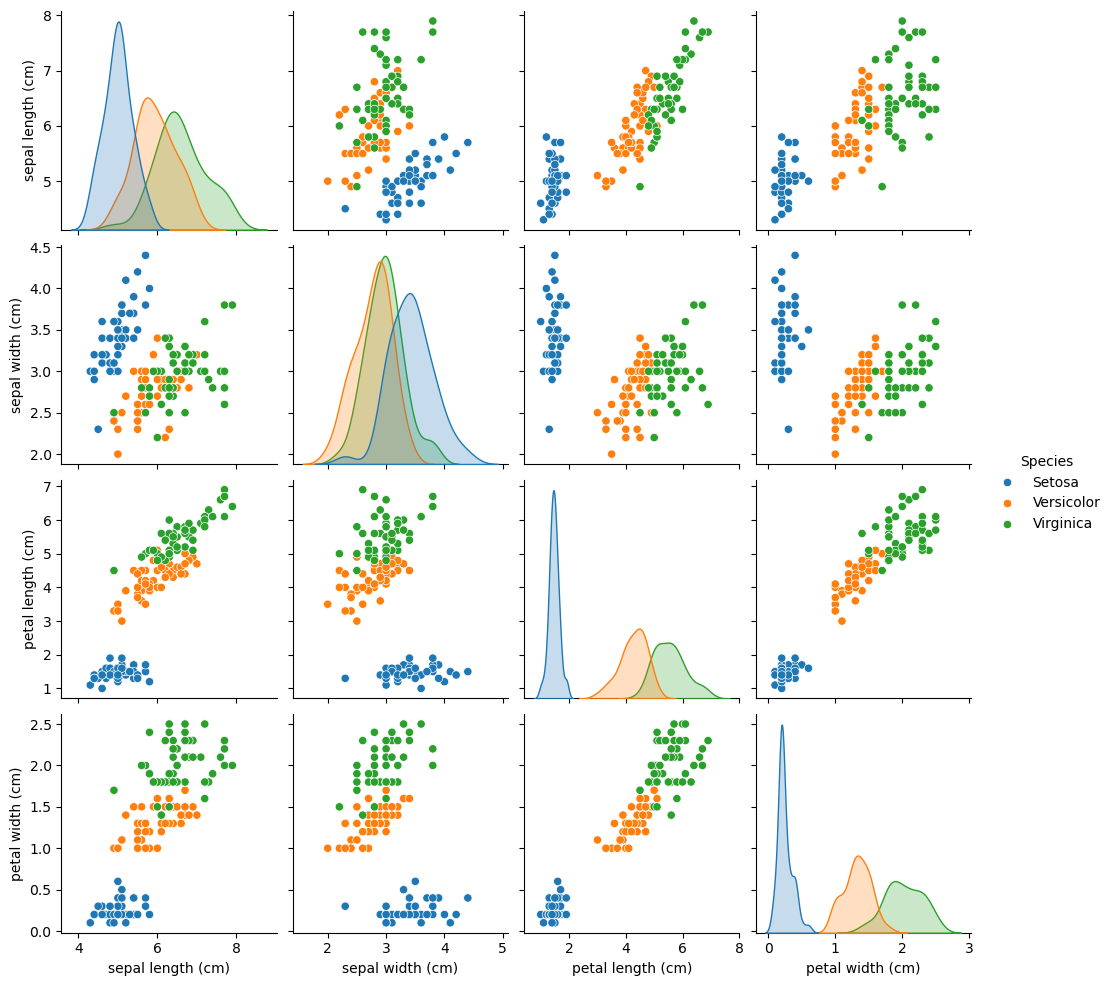

In [10]:
sns.pairplot(df, hue="Species")
plt.show()

# Interpretation:

1. The pairplot shows clear clustering of the three iris species based on their feature values.
2. Setosa is completely separated from the other two species, indicating it is the easiest to classify.
3. Versicolor and Virginica show some overlap, especially in sepal measurements, making them slightly harder to distinguish.
4. Petal length and petal width provide the best separation among species, making them the most discriminative features.
Overall, the pairplot suggests that the dataset is well-suited for classification models with high accuracy.

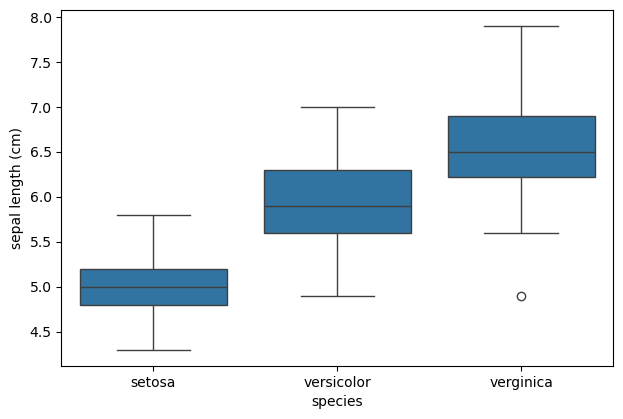

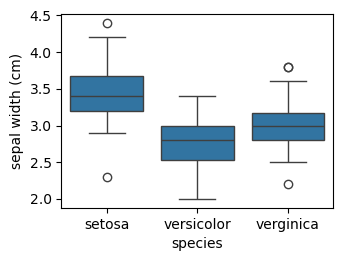

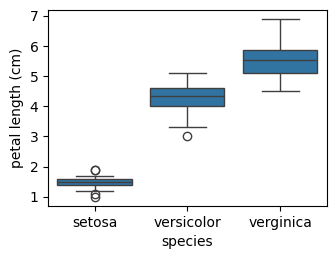

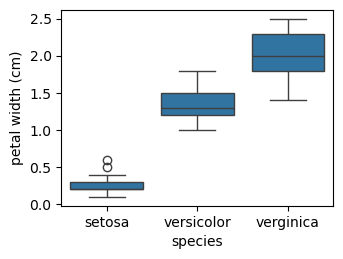

In [15]:

features=iris.feature_names
plt.figure(figsize=(12,8))
for i,feature in enumerate(features,1):
    plt.subplot(2,2,i)
    sns.boxplot(data=df,x="species",y=feature)
    plt.tight_layout()
    plt.show()


In [21]:
x=df[iris.feature_names]
y=df["species"]

In [25]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [26]:
from sklearn.linear_model import LogisticRegression

In [27]:
log_model=LogisticRegression(max_iter=200)
log_model.fit(x_train,y_train)
y_pred_log=log_model.predict(x_test)

In [28]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [29]:
log_accuracy=accuracy_score(y_test,y_pred_log)
log_accuracy

0.9

In [31]:
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)
y_pred_knn=knn_model.predict(x_test)

In [32]:
knn_accuracy=accuracy_score(y_test,y_pred_knn)
knn_accuracy

0.9333333333333333

In [33]:
knn_cm=confusion_matrix(y_test,y_pred_knn)
knn_cm

array([[10,  0,  0],
       [ 0,  8,  2],
       [ 0,  0, 10]], dtype=int64)

In [34]:
knn_cr=classification_report(y_test,y_pred_knn)
knn_cr

'              precision    recall  f1-score   support\n\n      setosa       1.00      1.00      1.00        10\n   verginica       1.00      0.80      0.89        10\n  versicolor       0.83      1.00      0.91        10\n\n    accuracy                           0.93        30\n   macro avg       0.94      0.93      0.93        30\nweighted avg       0.94      0.93      0.93        30\n'